# EDA: Initial Data Quality Audit & Late Delivery Baseline

**Project:** Supply Chain Optimization ML  
**Author:** Tirth Joshi, UBC MDS  
**Objective:** Requirement 2 — Identify key drivers of Late Delivery Risk in the DataCo Supply Chain dataset (180k records).  
**Data:** `data/raw/DataCoSupplyChainDataset.csv`

---

### Scope of This Notebook
1. **Data Quality Audit** — Shape, dtypes, missing values, duplicates
2. **Target Baseline** — Late delivery rate and class imbalance check
3. **Feature Leakage Audit** — Explicitly drop future-outcome columns
4. **Correlation Analysis** — Top 3 features driving Late Delivery Risk
5. **Key Findings Summary** — Interview-ready takeaways

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# ── Styling ───────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

DATA_PATH = Path('../data/raw/DataCoSupplyChainDataset.csv')
print(f'Loading data from: {DATA_PATH.resolve()}')

Loading data from: /Users/tirthjoshi/My Data Science Projects/ML_Portfolio_Projects/supply-chain-optimization-ml/data/raw/DataCoSupplyChainDataset.csv


---
## 1. Data Quality Audit

In [2]:
df = pd.read_csv(DATA_PATH, encoding='latin-1')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Shape: 180,519 rows × 53 columns


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


In [3]:
# ── Missing Values ────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Columns with missing data: {len(missing_report)}')
display(missing_report)

Columns with missing data: 4


,Missing Count,Missing %
Product Description,180519,100.00
Order Zipcode,155679,86.24
Customer Lname,8,0.00
Customer Zipcode,3,0.00


In [4]:
# ── Duplicate Rows ────────────────────────────────────────────────────
n_dupes = df.duplicated().sum()
print(f'Duplicate rows: {n_dupes:,} ({n_dupes/len(df)*100:.2f}%)')

# ── Data Types Summary ────────────────────────────────────────────────
print('\nColumn dtypes:')
print(df.dtypes.value_counts())

Duplicate rows: 0 (0.00%)

Column dtypes:
object     24
float64    15
int64      14
Name: count, dtype: int64


---
## 2. Target Baseline — Late Delivery Rate

> **Target variable:** `Late_delivery_risk` (1 = late, 0 = on time)  
> A critical first step: measure how imbalanced our classes are before choosing metrics.

In [5]:
target = 'Late_delivery_risk'

class_counts = df[target].value_counts()
class_pct    = df[target].value_counts(normalize=True).mul(100).round(2)

print('=== Late Delivery Risk — Class Distribution ===')
print(pd.DataFrame({'Count': class_counts, 'Percentage (%)': class_pct}).rename(index={0: 'On Time (0)', 1: 'Late (1)'}))

late_rate = class_pct.get(1, 0)
imbalance_ratio = class_counts.get(0, 0) / class_counts.get(1, 1)

print(f'\nBaseline Late Delivery Rate : {late_rate:.2f}%')
print(f'Class Imbalance Ratio (0:1) : {imbalance_ratio:.2f}:1')

if imbalance_ratio > 3:
    print('\n⚠️  Significant class imbalance detected. Prefer F1-score / PR-AUC over raw accuracy.')
else:
    print('\n✅  Classes are reasonably balanced. Accuracy remains a valid metric alongside F1.')

=== Late Delivery Risk — Class Distribution ===
                    Count  Percentage (%)
Late_delivery_risk                       
Late (1)            98977           54.83
On Time (0)         81542           45.17

Baseline Late Delivery Rate : 54.83%
Class Imbalance Ratio (0:1) : 0.82:1

✅  Classes are reasonably balanced. Accuracy remains a valid metric alongside F1.


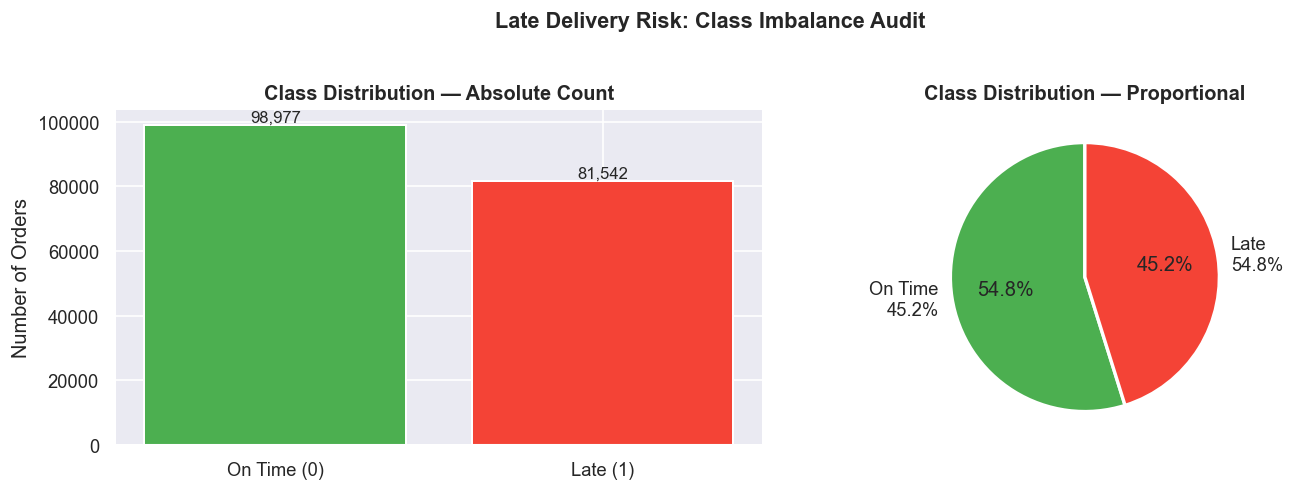

Figure saved to data/interim/class_distribution.png


In [6]:
# ── Visualise Class Distribution ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(
    ['On Time (0)', 'Late (1)'],
    class_counts.values,
    color=['#4CAF50', '#F44336'],
    edgecolor='white', linewidth=1.2
)
axes[0].set_title('Class Distribution — Absolute Count', fontweight='bold')
axes[0].set_ylabel('Number of Orders')
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{count:,}', ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(
    class_pct.values,
    labels=[f'On Time\n{class_pct[0]:.1f}%', f'Late\n{class_pct[1]:.1f}%'],
    colors=['#4CAF50', '#F44336'],
    startangle=90, autopct='%1.1f%%',
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[1].set_title('Class Distribution — Proportional', fontweight='bold')

plt.suptitle('Late Delivery Risk: Class Imbalance Audit', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/interim/class_distribution.png', bbox_inches='tight')
plt.show()
print('Figure saved to data/interim/class_distribution.png')

---
## 3. Leakage Audit — Dropping Future-Outcome Features

> **Integrity Check:** Any feature that would NOT be available at the moment of order placement must be excluded.  
> This is a non-negotiable step before any correlation analysis.

In [7]:
# Features that are post-hoc / future outcomes — EXCLUDED from all analysis
LEAKAGE_COLUMNS = [
    'Days for shipping (real)',   # The actual outcome — unknown at order time
    'Delivery Status',            # Directly encodes the outcome
    'shipping date (DateOrders)', # Post-event timestamp
]

# Also drop PII and irrelevant identifiers
PII_COLUMNS = [
    'Customer Email', 'Customer Password', 'Customer Fname',
    'Customer Lname', 'Customer Street', 'Product Description',
    'Product Image', 'Order Zipcode', 'Customer Zipcode'
]

DROP_COLS = LEAKAGE_COLUMNS + PII_COLUMNS
df_clean = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')

print(f'Original columns : {df.shape[1]}')
print(f'After leakage drop: {df_clean.shape[1]}')
print(f'\nDropped (Leakage) : {LEAKAGE_COLUMNS}')
print(f'Dropped (PII)     : {PII_COLUMNS}')

Original columns : 53


After leakage drop: 41

Dropped (Leakage) : ['Days for shipping (real)', 'Delivery Status', 'shipping date (DateOrders)']
Dropped (PII)     : ['Customer Email', 'Customer Password', 'Customer Fname', 'Customer Lname', 'Customer Street', 'Product Description', 'Product Image', 'Order Zipcode', 'Customer Zipcode']


---
## 4. Correlation Analysis — Top Drivers of Late Delivery Risk

In [8]:
# ── Numerical Correlations ────────────────────────────────────────────
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != target]

correlations = df_clean[numeric_cols + [target]].corr()[target].drop(target)
correlations_sorted = correlations.abs().sort_values(ascending=False)

print('=== Top 10 Numerical Features Correlated with Late Delivery Risk ===')
top10 = correlations[correlations_sorted.index[:10]]
print(top10.to_frame('Pearson Correlation').round(4))

=== Top 10 Numerical Features Correlated with Late Delivery Risk ===
                               Pearson Correlation
Days for shipment (scheduled)              -0.3694
Sales per customer                         -0.0038
Order Item Total                           -0.0038
Benefit per order                          -0.0037
Order Profit Per Order                     -0.0037
Sales                                      -0.0036
Order Item Profit Ratio                    -0.0023
Order Item Product Price                   -0.0022
Product Price                              -0.0022
Longitude                                  -0.0019


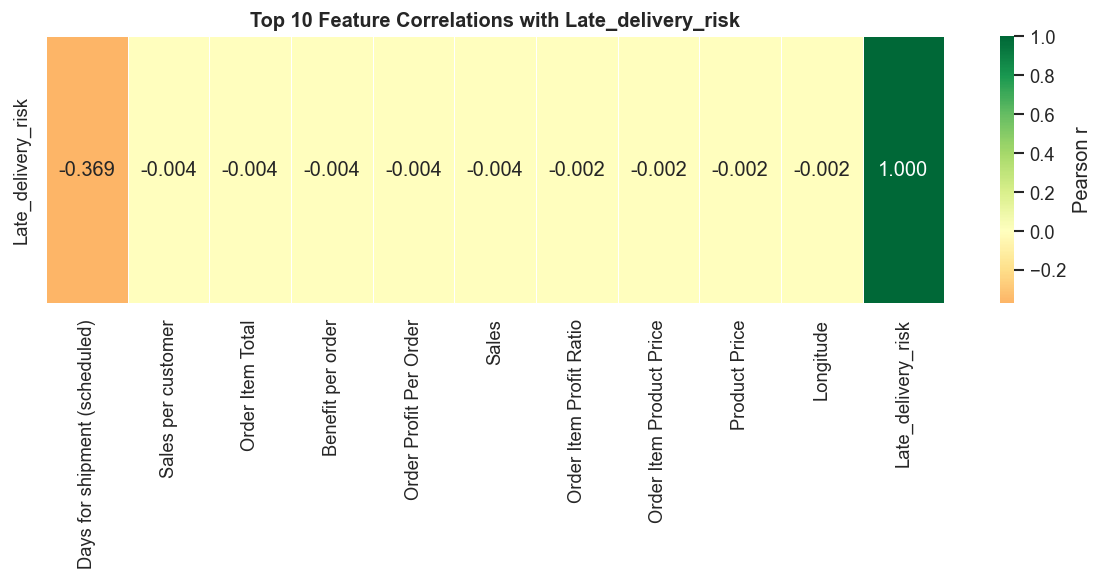

Figure saved to data/interim/correlation_heatmap.png


In [9]:
# ── Heatmap: Top 10 Correlations ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
top10_names = correlations_sorted.index[:10].tolist()
corr_matrix = df_clean[top10_names + [target]].corr()

sns.heatmap(
    corr_matrix[[target]].T,
    annot=True, fmt='.3f', cmap='RdYlGn',
    center=0, linewidths=0.5,
    cbar_kws={'label': 'Pearson r'},
    ax=ax
)
ax.set_title('Top 10 Feature Correlations with Late_delivery_risk', fontweight='bold', fontsize=12)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../data/interim/correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Figure saved to data/interim/correlation_heatmap.png')

=== Late Delivery Rate by Shipping Mode ===
                Late Rate (%)
Shipping Mode                
First Class             95.32
Second Class            76.63
Same Day                45.74
Standard Class          38.07


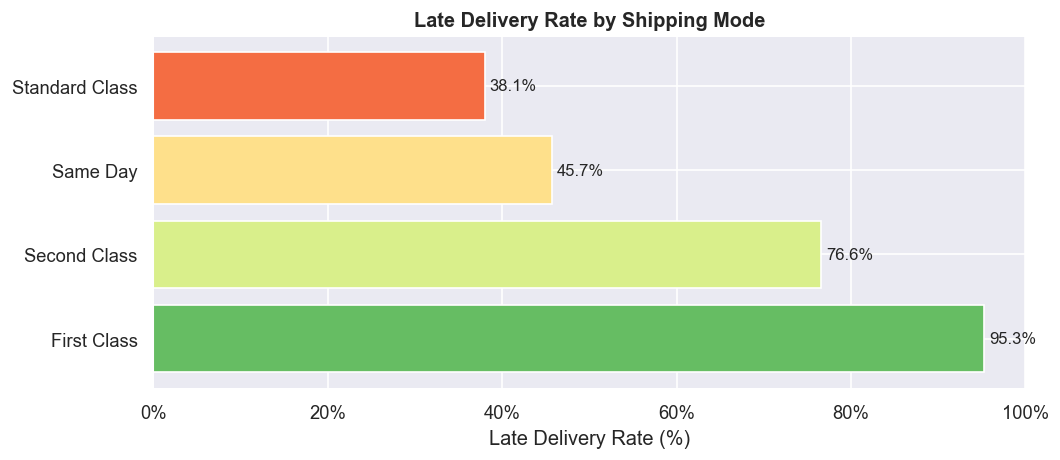

In [10]:
# ── Categorical Analysis — Shipping Mode ──────────────────────────────
if 'Shipping Mode' in df_clean.columns:
    shipping_late = df_clean.groupby('Shipping Mode')[target].mean().mul(100).round(2)
    shipping_late = shipping_late.sort_values(ascending=False)

    print('=== Late Delivery Rate by Shipping Mode ===')
    print(shipping_late.to_frame('Late Rate (%)'))

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.barh(shipping_late.index, shipping_late.values,
                   color=sns.color_palette('RdYlGn_r', len(shipping_late)),
                   edgecolor='white', linewidth=1)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlabel('Late Delivery Rate (%)')
    ax.set_title('Late Delivery Rate by Shipping Mode', fontweight='bold')
    for bar, val in zip(bars, shipping_late.values):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig('../data/interim/late_rate_by_shipping_mode.png', bbox_inches='tight')
    plt.show()

=== Top 10 Regions by Late Delivery Rate ===
                Late Rate (%)
Order Region                 
Central Africa          57.96
South Asia              56.27
East Africa             55.94
Western Europe          55.85
South of  USA           55.77
East of USA             55.66
Eastern Europe          55.66
Southeast Asia          55.53
Central Asia            55.33
West Asia               55.28


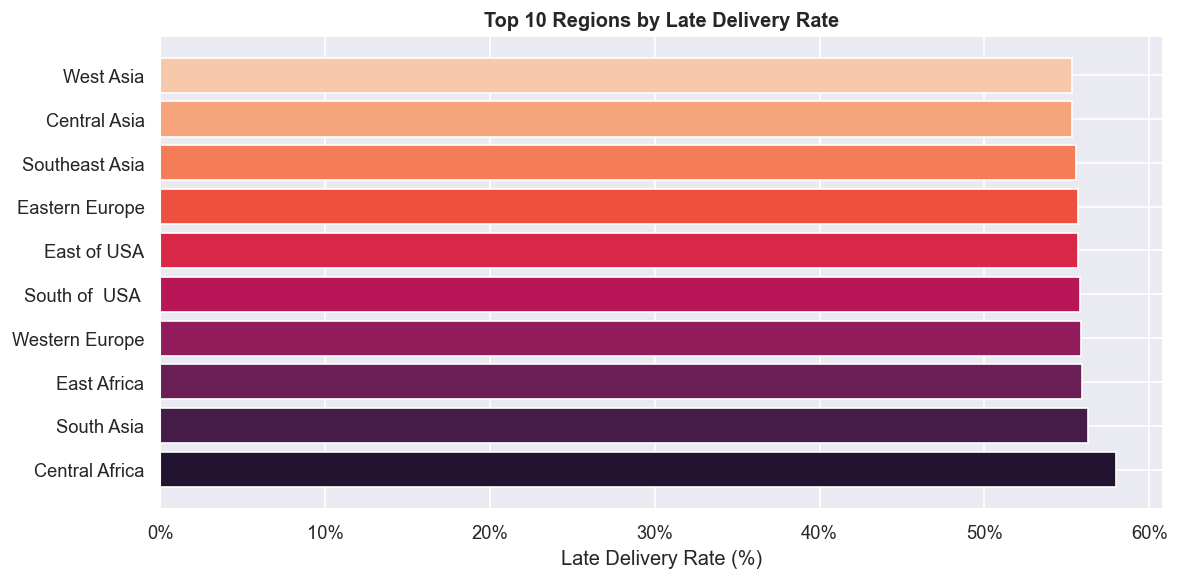

In [11]:
# ── Categorical Analysis — Order Region ───────────────────────────────
if 'Order Region' in df_clean.columns:
    region_late = df_clean.groupby('Order Region')[target].mean().mul(100).round(2)
    region_late = region_late.sort_values(ascending=False).head(10)

    print('=== Top 10 Regions by Late Delivery Rate ===')
    print(region_late.to_frame('Late Rate (%)'))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(region_late.index, region_late.values,
            color=sns.color_palette('rocket', len(region_late)),
            edgecolor='white', linewidth=1)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlabel('Late Delivery Rate (%)')
    ax.set_title('Top 10 Regions by Late Delivery Rate', fontweight='bold')
    plt.tight_layout()
    plt.savefig('../data/interim/late_rate_by_region.png', bbox_inches='tight')
    plt.show()

---
## 5. Key Findings Summary

> This section is updated after running the notebook. Use these findings to populate the LOCAL_PROJECT_STORY.md.

In [12]:
top3 = correlations_sorted.index[:3].tolist()
top3_vals = correlations[top3].round(4).to_dict()

print('=' * 55)
print('  KEY FINDINGS — Late Delivery Risk EDA')
print('=' * 55)
print(f'  Dataset shape      : {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'  Baseline late rate : {late_rate:.2f}%')
print(f'  Imbalance ratio    : {imbalance_ratio:.2f}:1 (On Time : Late)')
print()
print('  TOP 3 FEATURES CORRELATED WITH LATE DELIVERY:')
for i, (feat, corr) in enumerate(top3_vals.items(), 1):
    direction = 'positive' if corr > 0 else 'negative'
    print(f'  {i}. {feat:<40} r = {corr:+.4f}  ({direction})')
print()
print('  LEAKAGE AUDIT:')
print(f'  Excluded (leakage): {LEAKAGE_COLUMNS}')
print(f'  Excluded (PII)    : {len(PII_COLUMNS)} columns')
print('=' * 55)

  KEY FINDINGS — Late Delivery Risk EDA
  Dataset shape      : 180,519 rows × 53 cols
  Baseline late rate : 54.83%
  Imbalance ratio    : 0.82:1 (On Time : Late)

  TOP 3 FEATURES CORRELATED WITH LATE DELIVERY:
  1. Days for shipment (scheduled)            r = -0.3694  (negative)
  2. Sales per customer                       r = -0.0038  (negative)
  3. Order Item Total                         r = -0.0038  (negative)

  LEAKAGE AUDIT:
  Excluded (leakage): ['Days for shipping (real)', 'Delivery Status', 'shipping date (DateOrders)']
  Excluded (PII)    : 9 columns
